# 00 — Carga de datos y preprocesado base
Descarga datos del SP500, calcula log-retornos y muestra cómo funciona la ventana deslizante.
**Este notebook no entrena ningún modelo.** Sirve de referencia para los demás.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, yfinance as yf
warnings.simplefilter('ignore')

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS, RANDOM_SEED,
                   create_time_series_data, make_splits)

## 1. Descarga de precios de cierre

In [2]:
START_DATE = '1945-01-01'

precios = yf.download(TICKERS, start=START_DATE, auto_adjust=True, progress=True)['Close']
precios.dropna(axis=1, inplace=True)   # eliminar activos sin datos suficientes
print(f'Activos: {precios.shape[1]}  |  Días: {precios.shape[0]}')
precios.tail(3)

[*********************100%***********************]  23 of 23 completed

Activos: 23  |  Días: 16186


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-22,131.619995,231.279999,808.869995,42.119999,186.320007,104.820000,143.570007,108.129997,320.739990,276.290009,...,33.330002,226.100006,74.629997,68.070000,145.779999,65.180000,112.889999,441.660004,141.782379,149.500000
2026-04-23,135.080002,234.149994,835.239990,43.180000,187.600006,103.650002,147.399994,110.250000,318.709991,282.339996,...,33.540001,230.649994,76.279999,69.099998,144.839996,67.150002,114.620003,443.170013,144.621002,150.529999
2026-04-24,134.729996,232.440002,830.789978,42.470001,185.210007,102.599998,146.880005,109.059998,313.209991,284.600006,...,32.650002,227.500000,76.629997,67.230003,145.990005,66.879997,111.900002,438.260010,148.179993,148.910004


## 2. Log-retornos diarios
Transformación estándar: $r_t = \log(P_t) - \log(P_{t-1})$

Ventajas: estacionarios, aditivos, simetría entre subidas y bajadas.

<!-- [PREPROCESADO] Aquí se podría aplicar StandardScaler, Z-Score rolling,
     diferenciación fraccional (FFD) u otros preprocesados avanzados
     antes de crear las ventanas. Ver 07_investigacion.ipynb -->

Shape retornos: (16185, 23)


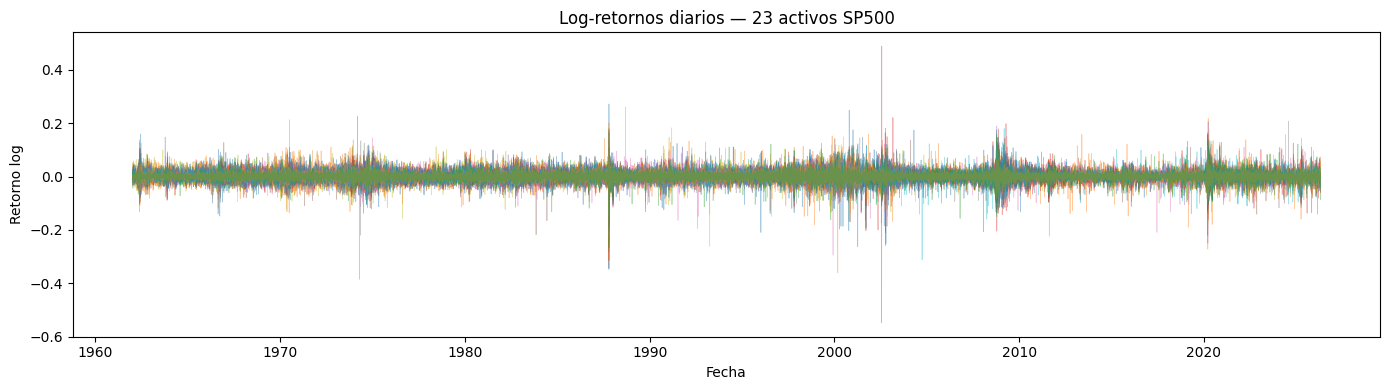

In [3]:
returns = np.log(precios).diff().dropna()
print(f'Shape retornos: {returns.shape}')   # (~16000, 23)

plt.figure(figsize=(14, 4))
plt.plot(returns, alpha=0.4, linewidth=0.5)
plt.title('Log-retornos diarios — 23 activos SP500')
plt.xlabel('Fecha'); plt.ylabel('Retorno log'); plt.tight_layout(); plt.show()

## 3. Ventanas deslizantes
La función `create_time_series_data` (la misma que Don Valero) genera:
- **X** `(N, V_in, 23)`: retornos de los últimos V_in días
- **y** `(N, 23)`: promedio del precio de cierre durante los V_out días futuros

In [4]:
# Ejemplo con V_in=10, V_out=5 (igual que el notebook base del profesor)
V_in, V_out = 10, 5
X, y = create_time_series_data(returns, V_in, V_out)
print(f'X: {X.shape}   y: {y.shape}')

X: (16171, 10, 23)   y: (16171, 23)


## 4. Partición train / val / test
**Partición 90/10 (train/test de clase)**, pero con 20% del train para Val — shuffle=False (serie temporal, orden cronológico):
- Paso 1: 90 % train_full / 10 % test
- Paso 2: 80 % train / 20 % val (del train_full)
- Resultado: ~72 % train / ~18 % val / 10 % test

In [5]:
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)
print(f'Train : X={X_tr.shape}  y={y_tr.shape}')
print(f'Val   : X={X_v.shape}   y={y_v.shape}')
print(f'Test  : X={X_ts.shape}  y={y_ts.shape}')

Train : X=(11642, 10, 23)  y=(11642, 23)
Val   : X=(2911, 10, 23)   y=(2911, 23)
Test  : X=(1618, 10, 23)  y=(1618, 23)


## 5. Resumen de tamaños por combinación de ventanas
Número de muestras disponibles para cada combinación (V_in, V_out).

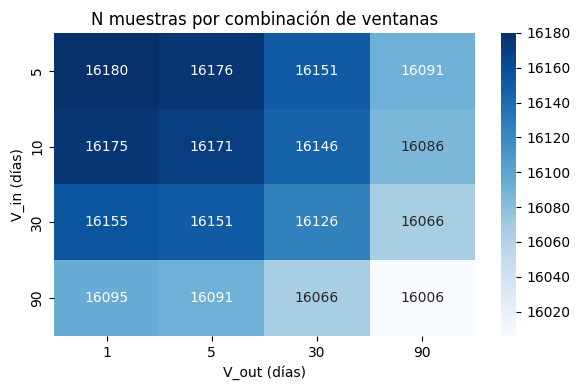

In [ ]:
n_samples = np.zeros((4, 4), dtype=int)
for i, vi in enumerate(INPUT_WINDOWS):
    for j, vo in enumerate(OUTPUT_WINDOWS):
        X_, _ = create_time_series_data(returns, vi, vo)
        n_samples[i, j] = len(X_)

df_n = pd.DataFrame(n_samples, index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS)
plt.figure(figsize=(6, 4))
sns.heatmap(df_n, annot=True, fmt='d', cmap='Blues')
plt.xlabel('V_out (días)'); plt.ylabel('V_in (días)')
plt.title('N muestras por combinación de ventanas'); plt.tight_layout(); plt.show()